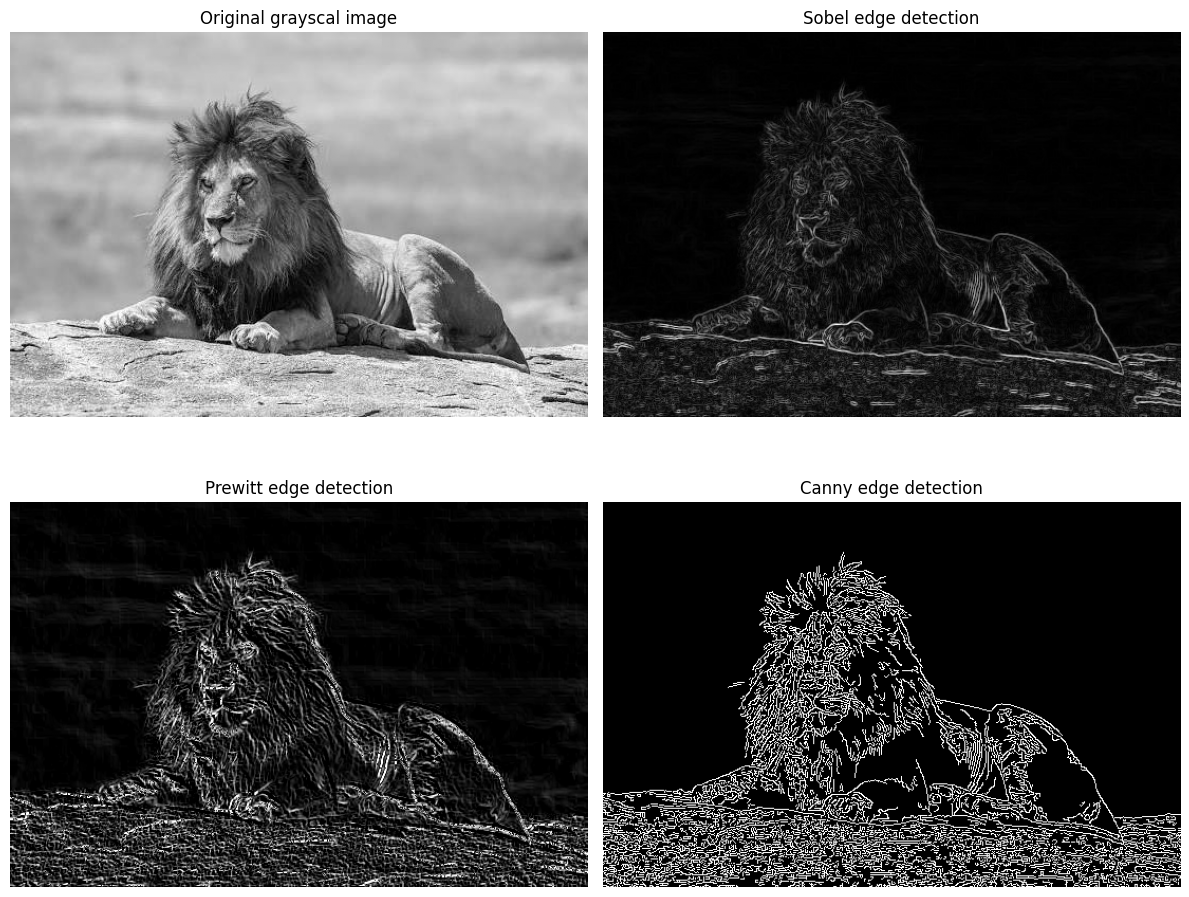

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#function to display images
def show_comparison(original,sobel,prewitt,canny):
  plt.figure(figsize=(12,10))
  plt.subplot(2,2,1)
  plt.imshow(original,cmap='gray')
  plt.title('Original grayscal image')
  plt.axis('off')

  #sodel edge detection
  plt.subplot(2,2,2)
  plt.imshow(sobel,cmap='gray')
  plt.title('Sobel edge detection')
  plt.axis('off')

  #prewitt edge detection
  plt.subplot(2,2,3)
  plt.imshow(prewitt,cmap='gray')
  plt.title('Prewitt edge detection')
  plt.axis('off')

  #canny edge detection
  plt.subplot(2,2,4)
  plt.imshow(canny,cmap='gray')
  plt.title('Canny edge detection')
  plt.axis('off')
  plt.tight_layout()
  plt.show()

#read a image
img=cv2.imread('/content/drive/MyDrive/images2.jpg',0)
if img is None:
  print('Error: Image not found')
else:
  #sobel operator
  #gradient in x & y direction
  sobelx=cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
  sobely=cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)
  #combine gradient
  sobel_combined=cv2.magnitude(sobelx,sobely)
  #prewitt operator
  #define kernel(px,py)
  kernelx=np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
  kernely=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
  #apply kernel useing filter2D
  prewittx=cv2.filter2D(img,-1,kernelx)
  prewitty=cv2.filter2D(img,-1,kernely)
  prewitt_combined=prewittx+prewitty
  #canny edge detection
  canny=cv2.Canny(img,100,200)
  #display images
  show_comparison(img,sobel_combined,prewitt_combined,canny)